# Week 4 - Day 3: Bias, Variance, and Model Fit

Today I focused on diagnosing model behavior instead of only looking for a higher score.

The main questions in this notebook are:

- Is the model too constrained and unable to learn the pattern well?
- Is the model too flexible and learning details that do not generalize?
- How can I use training and cross-validation scores together to tell the difference?
- How do hyperparameters change model complexity?
- When is reducing complexity actually useful?
- Why is a smaller train-validation gap not automatically a better model?

For this exercise I use the Breast Cancer Wisconsin dataset from Scikit-learn. It is a binary classification dataset, it is small enough to experiment with quickly, and it does not have the extreme class imbalance that made the previous dataset harder to use for this specific topic.

## 1. Imports

I keep the setup small because the goal is model diagnosis, not a large preprocessing workflow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)
from sklearn.tree import DecisionTreeClassifier

## 2. Load the dataset

The original Scikit-learn target uses `0 = malignant` and `1 = benign`.

For this notebook I remap it so that:

- `1 = malignant`
- `0 = benign`

This makes the F1 score focus on the malignant class, which is the class I want to detect.

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = (data.target == 0).astype(int)
y.name = "malignant"

print("Feature matrix shape:", X.shape)
print("\nClass counts:")
print(y.value_counts().rename(index={0: "benign", 1: "malignant"}))

print("\nClass proportions:")
print(
    y.value_counts(normalize=True)
     .rename(index={0: "benign", 1: "malignant"})
     .round(3)
)

Feature matrix shape: (569, 30)

Class counts:
malignant
benign       357
malignant    212
Name: count, dtype: int64

Class proportions:
malignant
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


The dataset has 569 samples and 30 numeric features. The classes are not perfectly balanced, but the imbalance is moderate enough for this exercise.

I will use F1 for the malignant class as the main metric. I still keep a simple baseline so that a score is not interpreted without context.

## 3. Hold out a final test set

I split off a test set before doing any model selection.

The important distinction is:

- During cross-validation, each validation fold is unseen by the model fitted in that fold.
- However, I still look at cross-validation results and use them to choose hyperparameters.
- Because CV influences my decisions, it is part of model development, not the final test.
- The held-out test set should stay untouched until the model choices are final.

For Day 3 I do not open the test score. The purpose here is to diagnose bias and variance using the development data.

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("Development set:", X_dev.shape)
print("Held-out test set:", X_test.shape)

Development set: (455, 30)
Held-out test set: (114, 30)


## 4. Cross-validation setup

I use 5-fold stratified cross-validation. Stratification keeps approximately the same class proportions in each fold.

For every model configuration I want three pieces of information:

1. Mean training F1
2. Mean validation F1 across the folds
3. Standard deviation of validation F1

The train-CV gap is useful for diagnosis, but it is not the objective by itself.

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


def evaluate_model(model, name):
    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv,
        scoring="f1",
        return_train_score=True,
    )

    train_mean = scores["train_score"].mean()
    cv_mean = scores["test_score"].mean()
    cv_std = scores["test_score"].std()

    return {
        "model": name,
        "train_f1": train_mean,
        "cv_f1_mean": cv_mean,
        "cv_f1_std": cv_std,
        "gap": train_mean - cv_mean,
    }

## 5. Baseline

Before diagnosing a real model, I want a reference point.

A classifier that always predicts the majority class can still get a reasonable-looking accuracy, but its F1 for malignant cases is zero. This is a reminder that the metric must match the actual prediction goal.

In [5]:
dummy = DummyClassifier(strategy="most_frequent")

baseline_scores = cross_validate(
    dummy,
    X_dev,
    y_dev,
    cv=cv,
    scoring={"f1": "f1", "accuracy": "accuracy"},
)

print(f"Baseline accuracy: {baseline_scores['test_accuracy'].mean():.3f}")
print(f"Baseline malignant F1: {baseline_scores['test_f1'].mean():.3f}")

Baseline accuracy: 0.626
Baseline malignant F1: 0.000


## 6. A deliberately underfit model

High bias does not mean that the model has many rules. It means the model is too restricted to represent the useful pattern well.

To make the underfitting case visible, I intentionally over-constrain a decision tree:

- `max_depth=1` allows only one level of splitting.
- `max_features=1` lets the split consider only one feature at a time.

This is a controlled failure case, not a serious final model candidate.

If both training and CV performance are weak, the model is not even learning the development data well enough. That is the behavior I expect from underfitting.

In [6]:
underfit_tree = DecisionTreeClassifier(
    max_depth=1,
    max_features=1,
    random_state=42,
)

underfit_result = evaluate_model(
    underfit_tree,
    "Deliberately constrained tree",
)

pd.DataFrame([underfit_result]).round(3)

,model,train_f1,cv_f1_mean,cv_f1_std,gap
0,Deliberately constrained tree,0.481,0.45,0.103,0.031


The training and CV scores are both low compared with what this dataset can support. Their closeness does not make this a good model.

A small gap can simply mean that the model is consistently weak.

This is why I should not choose a model only because train and validation scores are close.

## 7. A deliberately overfit model

Now I remove the tree constraints.

An unrestricted decision tree can keep splitting until it fits the training samples extremely closely. If training performance becomes nearly perfect while CV performance is clearly lower, the model is using capacity that does not fully transfer to unseen folds.

That is the behavior of high variance / overfitting.

In [7]:
overfit_tree = DecisionTreeClassifier(
    random_state=42,
)

overfit_result = evaluate_model(
    overfit_tree,
    "Unpruned tree",
)

pd.DataFrame([overfit_result]).round(3)

,model,train_f1,cv_f1_mean,cv_f1_std,gap
0,Unpruned tree,1.0,0.896,0.045,0.104


The unrestricted tree reaches perfect training F1, but the CV score is lower.

This does not mean the model is automatically unusable. CV performance is still the more important number during development because it measures behavior on unseen folds.

The gap is a diagnostic signal: it tells me that the model has learned training-specific detail that does not fully generalize. It also tells me there may be room to improve CV performance by reducing unnecessary complexity.

The goal is not to make the gap as small as possible. The goal is to get the strongest reliable unseen performance.

## 8. Use a hyperparameter to control complexity

For a decision tree, `min_samples_leaf` controls how many training samples must remain in a leaf.

- A very small value gives the tree more freedom.
- A larger value forces broader rules and reduces complexity.
- If I make it too large, the tree becomes too simple and can underfit.

I test several values using the same 5-fold CV procedure. Reusing CV for different hyperparameters is expected: this is exactly what validation is for.

Because I use these CV results to choose the setting, they are not a replacement for the final untouched test set.

In [8]:
leaf_values = [1, 2, 3, 5, 10, 20, 30, 50]
leaf_results = []

for leaf_size in leaf_values:
    tree = DecisionTreeClassifier(
        min_samples_leaf=leaf_size,
        random_state=42,
    )

    result = evaluate_model(
        tree,
        f"min_samples_leaf={leaf_size}",
    )
    result["min_samples_leaf"] = leaf_size
    leaf_results.append(result)

leaf_df = pd.DataFrame(leaf_results)

leaf_df[
    [
        "min_samples_leaf",
        "train_f1",
        "cv_f1_mean",
        "cv_f1_std",
        "gap",
    ]
].round(3)

,min_samples_leaf,train_f1,cv_f1_mean,cv_f1_std,gap
0,1,1.000,0.896,0.045,0.104
1,2,0.983,0.902,0.049,0.081
2,3,0.974,0.913,0.028,0.061
3,5,0.960,0.898,0.042,0.062
4,10,0.937,0.895,0.036,0.042
5,20,0.924,0.888,0.030,0.036
6,30,0.907,0.865,0.044,0.042
7,50,0.903,0.856,0.043,0.047


The table is more useful than looking only at the training score.

As the leaf size increases, the tree becomes more constrained. The best setting should be chosen from reliable CV performance, not from the smallest gap and not from the highest training score.

In [9]:
best_row = leaf_df.loc[leaf_df["cv_f1_mean"].idxmax()]

print("Best min_samples_leaf from CV:", int(best_row["min_samples_leaf"]))
print(f"Train F1: {best_row['train_f1']:.3f}")
print(f"CV F1: {best_row['cv_f1_mean']:.3f} ± {best_row['cv_f1_std']:.3f}")
print(f"Train-CV gap: {best_row['gap']:.3f}")

Best min_samples_leaf from CV: 3
Train F1: 0.974
CV F1: 0.913 ± 0.028
Train-CV gap: 0.061


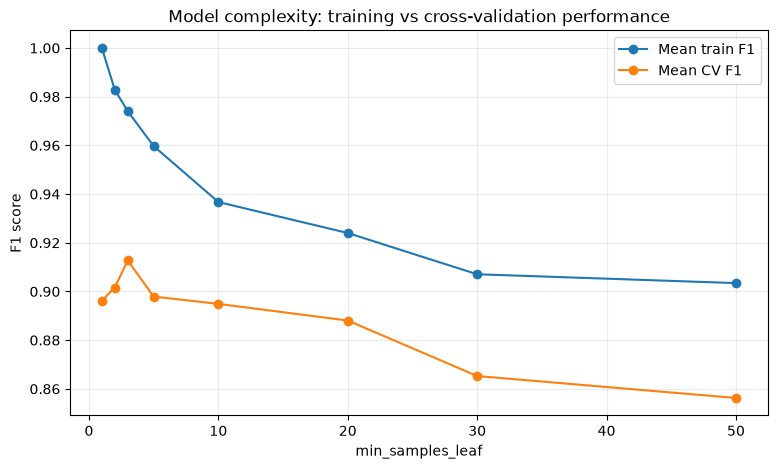

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    leaf_df["min_samples_leaf"],
    leaf_df["train_f1"],
    marker="o",
    label="Mean train F1",
)
plt.plot(
    leaf_df["min_samples_leaf"],
    leaf_df["cv_f1_mean"],
    marker="o",
    label="Mean CV F1",
)

plt.xlabel("min_samples_leaf")
plt.ylabel("F1 score")
plt.title("Model complexity: training vs cross-validation performance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. Fix the overfit case

The unrestricted tree had perfect training performance but lower CV performance.

The CV search shows that requiring a few samples in each leaf can improve generalization. This is the important part of the fix:

I am not trying to lower the training score on purpose. I accept a lower training score only if the change gives me better or more reliable unseen performance.

For example, these two situations are different:

- Train drops while CV improves: useful trade-off.
- Train drops while CV stays the same or gets worse: not an improvement just because the gap became smaller.

In [11]:
selected_leaf = int(best_row["min_samples_leaf"])

selected_tree = DecisionTreeClassifier(
    min_samples_leaf=selected_leaf,
    random_state=42,
)

selected_result = evaluate_model(
    selected_tree,
    f"Selected tree (min_samples_leaf={selected_leaf})",
)

comparison = pd.DataFrame(
    [
        underfit_result,
        overfit_result,
        selected_result,
    ]
)

comparison[
    [
        "model",
        "train_f1",
        "cv_f1_mean",
        "cv_f1_std",
        "gap",
    ]
].round(3)

,model,train_f1,cv_f1_mean,cv_f1_std,gap
0,Deliberately constrained tree,0.481,0.450,0.103,0.031
1,Unpruned tree,1.000,0.896,0.045,0.104
2,Selected tree (min_samples_leaf=3),0.974,0.913,0.028,0.061


The selected tree is a better development candidate because it gives stronger CV performance than the unrestricted tree while keeping the model less sensitive to individual training samples.

The unrestricted tree is a useful example of overfitting because perfect training performance did not give the best unseen performance.

The deliberately constrained tree is a useful example of underfitting because both training and CV performance were weak.

The selected model sits between these two extremes.

## 10. Bias-variance trade-off

The main idea is not that simple models are good and complex models are bad.

There is a trade-off:

- If the model is too constrained, bias is high and it underfits.
- Increasing useful capacity can reduce bias.
- If the model becomes too flexible, variance can become high and the model starts fitting training-specific detail.
- The useful region is the level of complexity that gives the best reliable generalization.

I should diagnose this from evidence, especially training performance, CV mean, CV variability, and a meaningful baseline.

## 11. Regularization: Ridge and Lasso

Regularization is another way to control effective model complexity.

For linear models, the curriculum introduces:

- **Ridge (L2):** penalizes large weights and shrinks them toward zero.
- **Lasso (L1):** also penalizes the weights and can push some of them exactly to zero.

The regularization strength is controlled by a hyperparameter such as `alpha`.

A larger regularization penalty makes the model more constrained. This can help an overfit model, but too much regularization can move the model into underfitting.



## 12. What I should read from train and CV scores

I use the scores for different jobs:

| Pattern | Likely diagnosis | What it suggests |
|---|---|---|
| Low train, low CV | Underfitting / high bias | The model is too restricted, the features are insufficient, or both |
| Very high train, clearly lower CV | Overfitting / high variance | The model is fitting training-specific details |
| Strong train, strong CV, reasonable gap | Better fit | The learned pattern is transferring well to unseen folds |

The gap is not a target by itself.

For example:

- `train = 0.78`, `CV = 0.77` is not automatically better than `train = 0.94`, `CV = 0.86`.
- If the CV estimates are reliable, the second model generalizes better even though its gap is larger.
- A model with strong CV can still be a good candidate even if some overfitting exists.
- I only try to reduce variance when I have a reason to believe I can improve or preserve unseen performance.

This is also why I do not regularize a model simply to make the train and CV numbers look closer.

## 13. Hyperparameters and validation

A hyperparameter can be one of the reasons a model underfits or overfits.

Examples in this notebook are:

- `max_depth`
- `max_features`
- `min_samples_leaf`

I do not need the hyperparameters to be correct before validation. Validation is the tool I use to judge different hyperparameter choices.

Trying many settings means I evaluate many models on validation folds. That is normal during development. It is also the reason the final test set has a separate role: I should not use the test set to choose the settings.

## 14. Final notes

From this experiment, the main engineering points I want to keep are:

1. Training performance alone is not enough.
2. Cross-validation performance is more important during development because it estimates behavior on unseen data.
3. Train-CV gap is a diagnostic signal, not the final objective.
4. High bias means the model is too constrained; it does not mean the model has many rules.
5. High variance means the model is too sensitive to the particular training data.
6. Hyperparameters can move a model between underfitting and overfitting.
7. Reducing complexity is useful only if the validation evidence supports the change.
8. The best model is not the one with the smallest gap. It is the one with the best reliable generalization for the problem.
9. CV is used repeatedly while developing the model, so the final test set must remain untouched.
10. Regularization is a complexity-control tool, not a method for making the training score lower.

I intentionally leave the held-out test set unevaluated here. The Day 3 objective is model-fit diagnosis and correction, not final model approval.